In [ ]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from scipy import signal

## Opgave 1
Antag at et signal $x[n]$ sendes igennem et LTI system med impulsrespons $h[n]$. Outputtet fra systemet betegnes med $y[n]$.

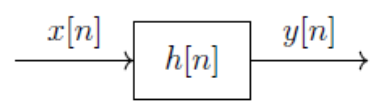

Lad impulsresponset være givet ved
$$
h[n] = \{3, \underset{\uparrow}{2}, -1\}
$$

Som sædvanligt angiver pilen $n=0$

### 1. Opskriv det analytiske udtryk for at beregne $y[1]$ og angiv hvor mange multiplikationer og additioner beregningen kræver.

Beregningen laves med en foldning, så der vil da laves 3 multiplikationer og 2 additioner. Det analytiske udtryk vil være

$$
y[1] = x[2] \cdot h[1-2] + x[1] \cdot h[1-1] + x[0] \cdot h[1-0] = x[2] \cdot 3 + x[1] \cdot 2 + x[0] \cdot (-1)
$$

### 2. Antag at signalet $x[n]$ er givet ved
$$
x[n] = \{\underset{\uparrow}{4}, 5, -6\}
$$
Beregn $y[1]$ for dette $x[n]$ signal.

Dette signal ville give $x[1]=5$, hvilket leder til følgende output
$$
y[1] = (-6) \cdot 3 + 5 \cdot 2 + 4 \cdot (-1) = -12
$$

### 3. Redegør for kausalitets- og stabilitetsegenskaberne af impulsresponset $h[n]$

Impulsresponset er ikke kausalt, da det har værdien $h[n]=3$ i $n=-1$.

Det er dog stabilt, da man kan summere alle elementerne og få et endeligt resultat, hvilket er
$$
\sum_{n=-\infty}^{\infty} h[n] = 3 + 2 - 1 = 4
$$

### 4. Antag at $x[n]$ sendes igennem LTI systemet to gange som vist nedenfor
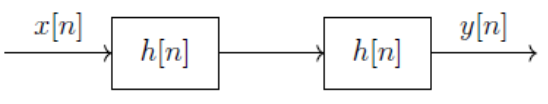

Beregn det totale impulsrespons for systemet

Hvis man sender $x[n]$ ind i impulsresponset to gange, vil det svare til, at impulsresponset er i en cascade connection (figur 3.8.b) med sig selv. Det totalte impulsrespons vil da blive lig $h[n]$ foldet med sig selv, hvilket kan beregnes i Python.

In [3]:
h = np.array([3,2,-1])
np.convolve(h, h)

array([ 9, 12, -2, -4,  1])

Her vil den midterste værdi (-2) forblive ved $n=0$, hvilket giver
$$
h_{total}[n] = \{ 9, 12, \underset{\uparrow}{-2}, -4, 1 \}
$$

## Opgave 2
Antag at et LTI system har systemfunktionen:
$$
H(z) = 1 + \alpha z^{-1}
$$

Der sendes et signal givet ved
$$
x[n] = \cos\left( \frac{\pi}{4} n \right), \quad -\infty < n < \infty
$$

igennem LTI systemet.

### 1. Beregn $\alpha$ således at amplituden af signalet halveres efter passage af filteret.

For at amplituden halveres skal størrelsen af systemfunktionen være $\frac{1}{2}$. Sættes $z=e^{j\omega}$ fås

\begin{align*}
|H(e^{ j\omega })| = \frac{1}{2} &= |1 + \alpha e^{ -j\omega }|\\
\frac{1}{2} &= |1 + \alpha \cos(\omega) - \alpha j\sin(\omega)|\\
\frac{1}{2} &= \sqrt{ (1 + \alpha \cos(\omega))^{2} + \alpha^{2}\sin^{2}(\omega) }
\end{align*}

Her vides det at der kigges på frekvensen $\omega = \frac{\pi}{4}$, da det vil resultere i den maksimale værdi og dermed amplituden af $x[n]$. Denne ligning kan løses med python.

In [ ]:
a = sp.symbols('alpha')
sp.solve(sp.sqrt((1 + a*sp.cos(sp.pi/4))**2 + (a*sp.sin(sp.pi/4))**2) - 1/2, a)

[-0.707106781186548 - 0.5*I, -0.707106781186548 + 0.5*I]

For at signalet halveres skal $\alpha$ være komplekst og have værdien
$$
\alpha = -0.71 \pm \frac{1}{2}j
$$

eller mere præcist
$$
\alpha = -\frac{1}{\sqrt{2}} \pm \frac{1}{2}j
$$

### 2. Hvordan påvirkes fasen af signalet gennem LTI systemet?

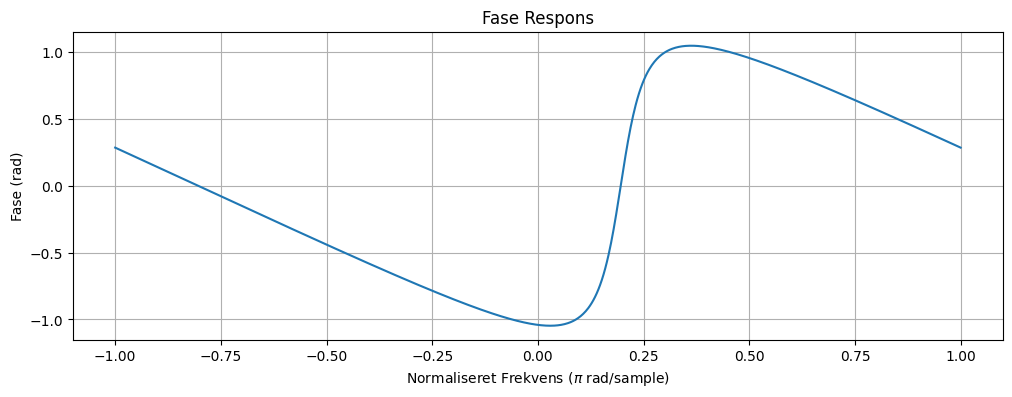

In [11]:
w = np.linspace(-np.pi, np.pi, 1000)
a = - (1/np.sqrt(2)) - 1j/2
H = 1 + a * np.exp(-1j * w)

plt.figure(figsize=(12, 4))

plt.plot(w / np.pi, np.angle(H))
plt.title('Fase Respons')
plt.xlabel('Normaliseret Frekvens ($\pi$ rad/sample)')
plt.ylabel('Fase (rad)')
plt.grid(True)
plt.show()

Det kan ses at fasen vil blive forvrænget på ikke lineær vis, hvilket vil forvrænge signalet.

### 3. Antag at signalet ikke er uendelig langt, men derimod starter til $n=0$, dvs
$$
x[n] = \cos\left( \frac{\pi}{4} n \right) u[n]
$$

Hvor $u[n]$ som sædvanligt betegner stepfunktionen. Den pludselige start på signalet giver anledning til en transient forvrængning.

Estimer hvor mange samples den transiente forvrængning varer.

c:\Users\henri\AppData\Local\Programs\Python\Python310\lib\site-packages\matplotlib\cbook\__init__.py:1369: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


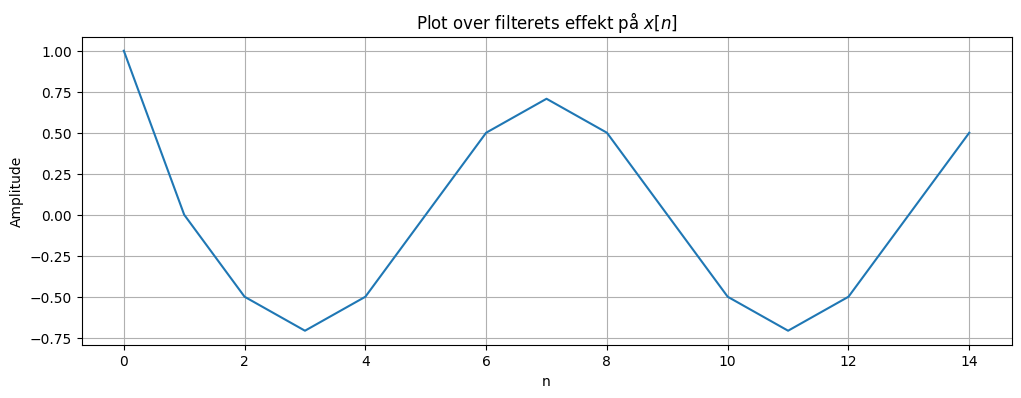

In [19]:
# Filter coefficient (choose α from your calculation, here for demonstration α=0.8)
alpha = - (1/np.sqrt(2)) - 1j/2
b = [1, alpha]  # FIR filter coefficients
a = [1]         # Denominator for FIR

# Generate input signal x[n] = cos(pi/4 n) u[n]
N = 15
n = np.arange(N)
x = np.cos(np.pi/4 * n)

# Filter the signal
y = signal.lfilter(b, a, x)

# Plot input and output
plt.figure(figsize=(12, 4))
plt.plot(n, y)
plt.xlabel('n')
plt.ylabel('Amplitude')
plt.title('Plot over filterets effekt på $x[n]$')
plt.grid(True)
plt.show()


In [20]:
3*np.sqrt(2)/4

1.0606601717798214

Det kan ses at der er transient forvrængning i ca. 1 sample.

## Opgave 3
Lad et LTI system være givet som en parallelkobling af to 1. ordens IIR filtre.

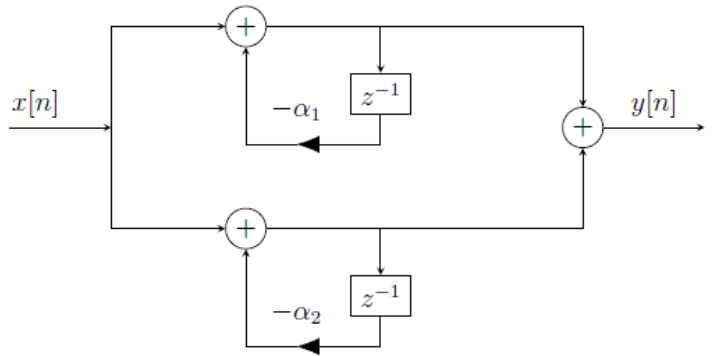

### 1. Hvilke krav er der på $\alpha_1$ og $\alpha_2$ for at systemet er stabilt?

Begge IIR filtre kan skrives op som
$$
y_i[n] = x[n] - \alpha_{i} y_i[n-1]
$$

hvor det samlet system ville være
$$
y[n] = y_1[n] + y_2[n] = 2x[n] - \alpha_{1} y_i[n-1] - \alpha_{2} y_i[n-1]
$$

Systenfunktionen for IIR filtrene ville da være

\begin{align*}
Y_{i}(z) &= X(z) - \alpha_{i} z^{-1}Y_{i}(z)\\
H_{i} = \frac{Y_{i}(z)}{X(z)} &= \frac{1}{1 + \alpha_{i}z^{-1}}
\end{align*}

Resultat 3.5.3 fra bogen siger at et system vil være stabilt, hvis alle polerne ligger indenfor enhedscirklen $z=0$. Det kan ses at polerne for IIR filtrene vil være i $z = -\alpha_i$. Dermed er kravet for begge $\alpha_i$ værdier at de skal være under 1, hvilket vil ligge begge poler indenfor enhedscirklen. Dermed er kravet
$$
|\alpha_1| < 1 \quad \text{og} \quad |\alpha_2| < 1
$$

### 2. Beregn systemfunktionen, $H(z)$, og impulsresponset, $h[n]$, for LTI systemet.

Den samlede systemfunktion vil være summen af de to filtres systemfunktioner

\begin{align*}
H(z) &= H_{1}(z) + H_{2}(z)\\
&= \frac{1}{1 + \alpha_{1}z^{-1}} + \frac{1}{1 + \alpha_{2}z^{-1}}
\end{align*}

Impulsresponset kan derefter findes ved at invers $Z$-transformere igen.
$$
h[n] = ((-\alpha_1)^n + (-\alpha_2)^n) u[n]
$$

### 3. Tegn den direkte form II struktur, der svarer til LTI systemet med angivelse af a og b koefficienter udtrykt ved $\alpha_1$ og $\alpha_2$

Samles brøken fra forrige opgave fås

\begin{align*}
\frac{Y(z)}{X(z)} &= \frac{1}{1 + \alpha_{1}z^{-1}} + \frac{1}{1 + \alpha_{2}z^{-1}}\\
&= \frac{1 + \alpha_{1}z^{-1} + 1 + \alpha_{2}z^{-1}}{(1 + \alpha_{1}z^{-1})(1 + \alpha_{2}z^{-1})}\\
&= \frac{2 + \alpha_{1}z^{-1} + \alpha_{2}z^{-1}}{1 + \alpha_{2}z^{-1} + \alpha_{1}z^{-1} + \alpha_{1}\alpha_{2}z^{-2}}
\end{align*}

Dette tegnes således

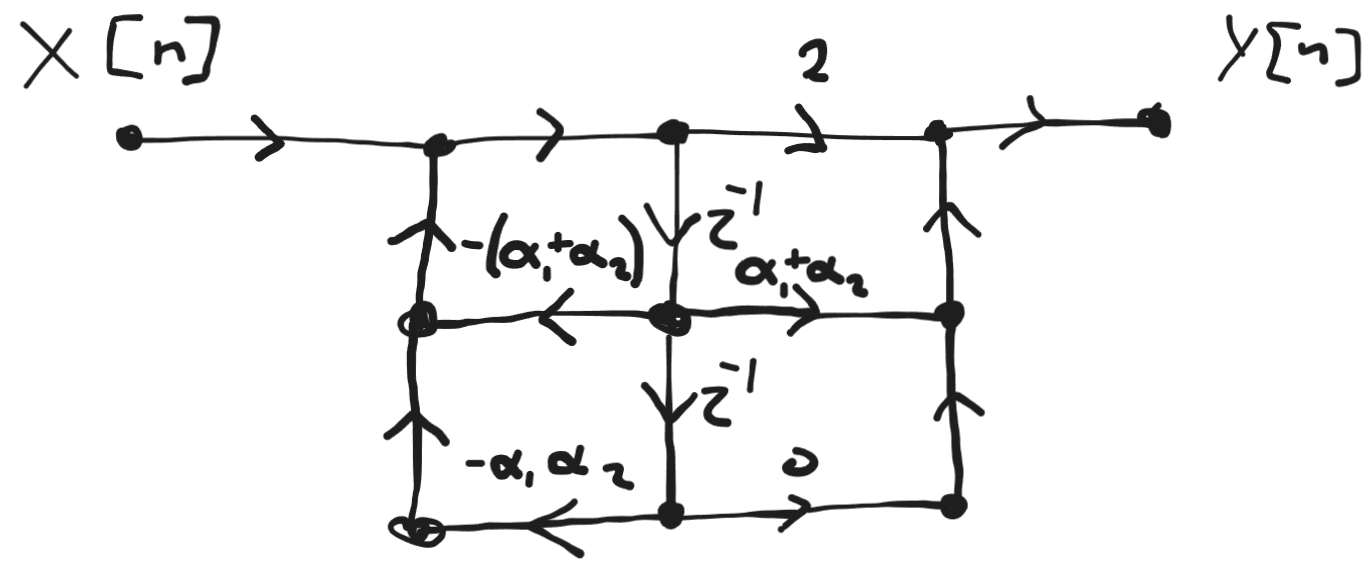

## Opgave 4
Et Lineær Tidsinvariant (LTI) digitalt system $S$ har input signal $x[n]$, output signal $y[n]$ og systemet er givet ved differensligningen:
$$
S: y[n] = \frac{1}{2} y[n - 1] - \frac{1}{2} x[n] + x[n - 1]
$$

Lad os antage at: 
$$
y[0] = 0, \text{når } n \leq 0 
$$

og lad et signal $x[𝑛]$ være givet ved: 
$$
x[n] =
\begin{cases}
(-1)^{n} & \text{når } n \geq 0, \\
0 & \text{ellers}
\end{cases}
$$

### 1. Beregn $y[1]$, $y[2]$ og $y[3]$, idet input signalet er $x[𝑛]$ ovenfor

Beregning af $y[1]$

\begin{align*}
y[1] &= \frac{1}{2} y[0] - \frac{1}{2} x[1] + x[0]\\
&= \frac{1}{2} \cdot 0 - \frac{1}{2} \cdot (-1) + 1\\
&= \frac{3}{2}
\end{align*}

Beregning af $y[2]$

\begin{align*}
y[2] &= \frac{1}{2} y[1] - \frac{1}{2} x[2] + x[1]\\
&= \frac{1}{2} \cdot \frac{3}{2} - \frac{1}{2} \cdot 1 + (-1)\\
&= -\frac{3}{4}
\end{align*}

Beregning af $y[3]$

\begin{align*}
y[3] &= \frac{1}{2} y[2] - \frac{1}{2} x[3] + x[2]\\
&= \frac{1}{2} \cdot \left( -\frac{3}{4} \right) - \frac{1}{2} \cdot (-1) + 1\\
&= \frac{9}{8}
\end{align*}

### 2. Beregn $Z$-transformationen $H(z)$ for overføringsfunktionen for $S$, inklusiv dennes ROC.

\begin{align*}
Y(z) &= \frac{1}{2} z^{-1} Y(z) - \frac{1}{2} X(z) + z^{-1} X(z)\\
Y(z) - \frac{1}{2} z^{-1} Y(z) &= - \frac{1}{2} X(z) + z^{-1} X(z)\\
H(z) = \frac{Y(z)}{X(z)} &= \frac{-\frac{1}{2} + z^{-1}}{1 - \frac{1}{2}z^{-1}}
\end{align*}

Den har en pol i $z=\frac{1}{2}$ pga. leddet $\frac{1}{2}z^{-1}$. Da systemet er et kausalt system vil funktionen konvergere i
$$
ROC: |z| > \frac{1}{2}
$$

### 3. Er systemet stabilt eller ustabilt? (argumenter for dit svar)

Det er stabilt da polen $z=\frac{1}{2}$ ligger indenfor enhedscirklen $|z|=1$ jvf. resultat 3.5.3.

### 4. Skitser grafen for $|H( e^{ j\omega } )|$, er $|H( e^{ j\omega } )|$ periodisk?

Den skulle meget gerne være periodisk med en periode på $2 \pi$, da $|H( e^{ j\omega } )| = |H( e^{ j(\omega + 2\pi) } )|$

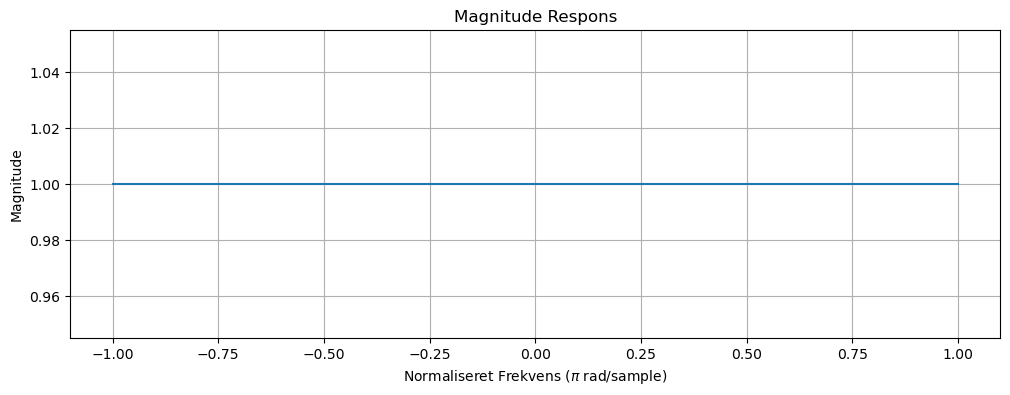

In [9]:
num = [-1/2, 1]
den = [1, -1/2]

w = np.linspace(-np.pi, np.pi, 1000)
_, H = signal.freqz(num, den, worN=w)

plt.figure(figsize=(12, 4))

plt.plot(w / np.pi, np.abs(H))
plt.title('Magnitude Respons')
plt.xlabel('Normaliseret Frekvens ($\pi$ rad/sample)')
plt.ylabel('Magnitude')
plt.grid(True)
plt.show()

### 5. Lad 𝑇 være et Lineær Tidsinvariant (LTI) digitalt system givet ved differenceligningen: 
$$
T: y[n] = x[n] + \alpha \cdot x[n − 1],
$$

hvor $\alpha$ er et reelt tal.

Findes der et tal $\alpha$ således at kaskade koblingen af $T$ og $S$ er et system med endeligt impuls svar? (argumenter for dit svar)

Kaskade koblingen mellem de to systemer kan beskrives som produktet af deres systemfunktioner $H_S(z)$ og $H_T(z)$, hvor den første er fundet i opgave 4.2 og den anden er

\begin{align*}
Y_T(z) &= X(z) + \alpha z^{-1} X(z)\\
H_T(z) = \frac{Y_T(z)}{X(z)} &= 1 + \alpha z^{-1}
\end{align*}

Det koblede system er da

$$
H_S(z) \cdot H_T(z) = \frac{-\frac{1}{2} + z^{-1}}{1 - \frac{1}{2}z^{-1}} \cdot (1 + \alpha z^{-1})
$$

For at gøre et IIR system til et FIR system kan man fjerne dets poler, og dermed fjerne feedback i systemet. I dette tilfælde vil $H_T(z)$ faktoren gå ud med hele nævneren, hvis $\alpha = -\frac{1}{2}$, hvilket også ville fjerne polen.

$$
H_S(z) \cdot H_T(z) = -\frac{1}{2} + z^{-1}, \quad \alpha = - \frac{1}{2}
$$

Dette vil være et system med et endeligt impuls svar. Der skal det gælde at
$$
\alpha = - \frac{1}{2}
$$

## Opgave 5
Et analogt signal $x_c(t)$ er en superposition af 2 rene sinustoner, med samme amplitude. De to toner har frekvenser på helholdsvis $F_1 = 1200 Hz$ og $F_2 = 1300 Hz$. Vi sampler $x_c(t)$ i 10msec.

### 1. Hvilken samplingsfrekvens vil du forslå at vi bruger, hvis vi skal kunne adskille de to sinustoner når i ser på frekvensspektret? (Angiv dit svar i hertz og argumenter for dit svar). 

Med den givne observationsperiode på 10ms, så vil der være en frekvensopløsning på
$$
\Delta f = \frac{1}{T_0} = \frac{1}{0.01s} = 100 Hz
$$

Det ville da være mulig at adskille frekvenser, som ligger mindst 100 Hz fra hinanden, hvilket sinustonerne i dette tilfælde er da
$$
F_2 - F_1 = 1300 Hz - 1200 Hz = 100 Hz
$$

Samplingsfrekvensen kan derefter vælges ud fra Nyquist kriteriet. Den højeste frekvens i signalet er 1300 Hz, så samplingsfrekvensen skal være minimum 2600 Hz for at undgå aliasing. For ekstra margin kunne man vælge
$$
f_s = 3000 Hz
$$

### 2. Vi anvender en tidsvinduesfunktion i forbindelse med frekvensanalyse i spørgsmål 1 (f.eks. et Hamming vindue eller et andet vindue). Hvilken indflydelse vil valget af vinduesfunktion have på dit svar i spørgsmål 1, og hvilket vindue vil du anbefale at bruge? (argumenter for dit svar).

Vinduet ville ikke som sådan ændre på valget af samplingfrekvensen, da frekvensen er bestemt ud fra nyquist kriteriet. Da frekvenserne ligger meget tæt på hinanden og lige på grænsen af samplingsopløsningen, ville jeg anbefale at bruge et hamming vindue, da den har de mindste sidelober.

### 3. Goertzels algoritme er en almindelig metode at bruge når man vil afgøre om en bestemt ren sinustone er til stede i et diskret signal $x[n]$, idet man kan beregne den $k$'te DFT-koefficient $X[k]$ ud fra den rekursive formel:
$$
y_k[n] = W_N^{-k}(t) y_k[n - 1] + x[n], \quad 0 \leq n \leq N
$$
$$
X[k] = y_k[N],
$$

hvor N er blok-længden og $W_N = e^{ -j \frac{2\pi}{N} }$.

Beregn $N$, når vi sampler $x_c(t)$ i 10msec. med en samplingsfrekvens på 3000 $Hz$ og beregn herefter $k$ således at Goertzels algoritmen er tunet ind til afgøre om en ren sinustone med frekvens 1200 $Hz$ er til stede i $x_c(t)$.  

Bloklængden svarer til antallet af samples, hvilket kan beregnes som samplingsfrekvensen ganget med observationsperioden
$$
N = f_s \cdot T_0 = 3000 \cdot 0.01 = 30
$$

$k$ svarer til den bin eller del man kigger på i sine samples. En given bin vil starte i frekvensen
$$
f = \frac{k \cdot f_s}{N}
$$

Indsættes 1200 Hz frekvensen kan $k$ da isoleres og bestemmes som
$$
k = \frac{1200 \cdot 30}{3000} = 12
$$